# Preprocessing Notebook

This notebook prepares the financial-news sentiment dataset for the modeling notebooks. It loads the Hugging Face dataset, creates train/validation/test splits, cleans tweet text, checks data quality, visualizes class and token distributions, computes class weights, and saves reusable artifacts for BERT, GPT, and GAN experiments.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import os

from datasets import load_dataset
from collections import Counter


pd.set_option("display.max_colwidth", None)
nltk.download('punkt')
nltk.download('stopwords')

c:\Users\dusti\Documents\Code\DS4\DS4_ACT4_MVTAnalysisNGeneration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dusti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dusti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Environment Setup

Import the data, plotting, text-processing, and utility libraries used throughout preprocessing. The NLTK downloads provide tokenization support for the vocabulary summary near the end of the notebook.


In [4]:
raw = load_dataset("zeroshot/twitter-financial-news-sentiment")

train_data = raw["train"]

# Manually carve val + test from the provided validation split
val_test = raw["validation"].train_test_split(test_size=0.5, seed=42)
val_data  = val_test["train"]   # ~1,194 rows
test_data = val_test["test"]    # ~1,195 rows

print(f"Train : {len(train_data)}")
print(f"Val   : {len(val_data)}")
print(f"Test  : {len(test_data)}")

Train : 9543
Val   : 1194
Test  : 1194


## 2. Load Dataset and Create Splits

Load zeroshot/twitter-financial-news-sentiment from Hugging Face. The dataset already provides a training split; the original validation split is divided evenly into validation and test sets with a fixed seed so downstream notebooks can reproduce the same evaluation data.


In [5]:
train_df = pd.DataFrame(train_data)
val_df   = pd.DataFrame(val_data)
test_df  = pd.DataFrame(test_data)

# Rename label column for clarity
label_map = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
for df in [train_df, val_df, test_df]:
    df["sentiment"] = df["label"].map(label_map)

train_df.head()

,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0,Bearish


## 3. Convert to DataFrames and Add Labels

Convert each split to a pandas DataFrame and map numeric labels into readable sentiment names: Bearish, Bullish, and Neutral. The original numeric label column is retained because model-training code uses it directly.


In [6]:
def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'\$[A-Z]+', '<STOCK>', text) # replace stock tickers
    text = re.sub(r'@\w+', '<MENTION>', text)        # replace mentions
    text = re.sub(r'#(\w+)', r'\1', text)         # strip hashtag symbol
    text = re.sub(r'\n', ' ', text)                     # removes new line formating
    text = re.sub(r'[^\x00-\x7F]+', '', text)            # removes all emojis by targeting the usual unicode of emojis
    text = re.sub(r'\s+', ' ', text).strip()      # collapse whitespace
    return text

train_df["clean_text"] = train_df["text"].apply(clean_tweet)
val_df["clean_text"]   = val_df["text"].apply(clean_tweet)
test_df["clean_text"]  = test_df["text"].apply(clean_tweet)

# Sanity check
train_df[["text", "clean_text"]].head(3)

,text,clean_text
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,<STOCK> - JPMorgan reels in expectations on Beyond Meat
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,<STOCK> <STOCK> - Nomura points to bookings weakness at Carnival and Royal Caribbean
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb","<STOCK> - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook"


## 4. Clean Tweet Text

Normalize noisy social-media text while preserving sentiment-bearing content. URLs are removed, stock tickers and mentions are replaced with placeholders, hashtag markers are stripped, emojis/non-ASCII characters are removed, and whitespace is collapsed into a consistent format.


In [7]:
print("=== Nulls ===")
print(train_df.isnull().sum())

print("\n=== Duplicates in train ===")
print(train_df.duplicated(subset="clean_text").sum())

# Drop duplicates if any
train_df.drop_duplicates(subset="clean_text", inplace=True)
print(f"Train size after dedup: {len(train_df)}")

=== Nulls ===
text          0
label         0
sentiment     0
clean_text    0
dtype: int64

=== Duplicates in train ===
118
Train size after dedup: 9425


## 5. Data Quality Checks

Inspect null values and duplicate cleaned tweets in the training split. Duplicate training examples are removed so the model does not overfit repeated text patterns.


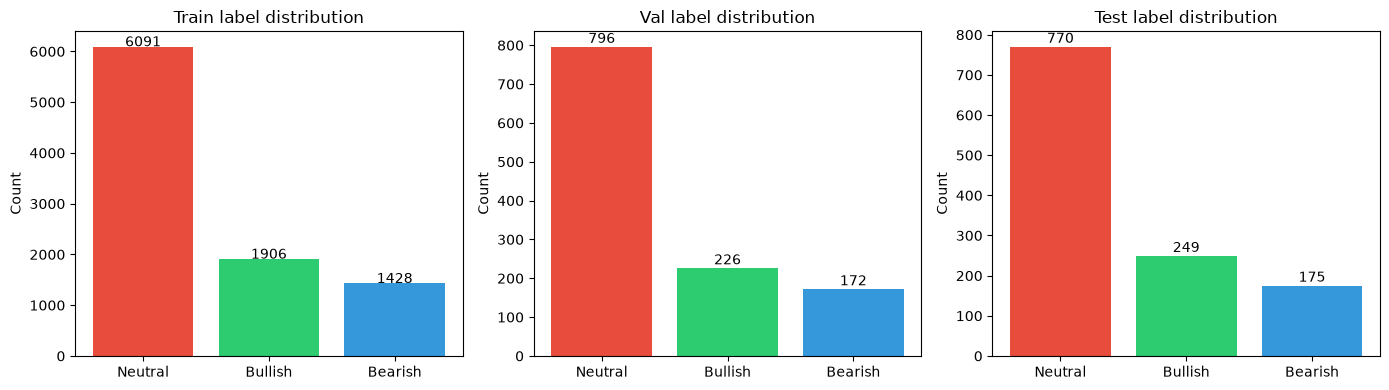

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = {"Train": train_df, "Val": val_df, "Test": test_df}

for ax, (name, df) in zip(axes, splits.items()):
    counts = df["sentiment"].value_counts()
    ax.bar(counts.index, counts.values,
           color=["#e74c3c", "#2ecc71", "#3498db"])
    ax.set_title(f"{name} label distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../results/figures/label_distribution.png", dpi=150)
plt.show()

## 6. Label Distribution

Plot the class balance for train, validation, and test splits. This makes it easier to spot skew that could affect evaluation or motivate weighted training.


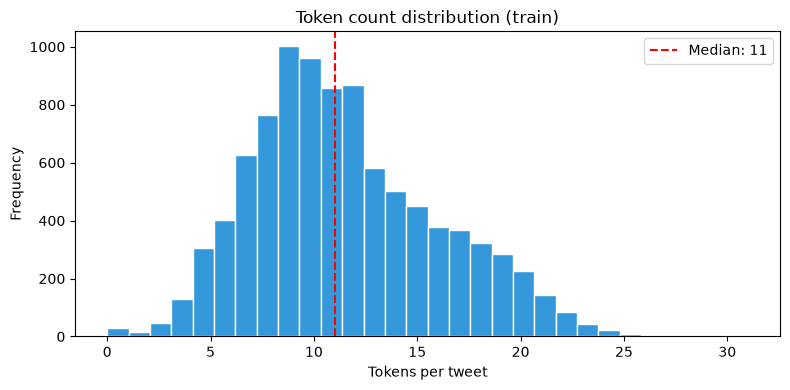

count    9425.000000
mean       11.653156
std         4.379387
min         0.000000
25%         9.000000
50%        11.000000
75%        14.000000
max        31.000000
Name: token_count, dtype: float64


In [9]:
train_df["token_count"] = train_df["clean_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(train_df["token_count"], bins=30, color="#3498db", edgecolor="white")
plt.axvline(train_df["token_count"].median(), color="red",
            linestyle="--", label=f'Median: {train_df["token_count"].median():.0f}')
plt.title("Token count distribution (train)")
plt.xlabel("Tokens per tweet")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/token_length_distribution.png", dpi=150)
plt.show()

print(train_df["token_count"].describe())

## 7. Token Length Distribution

Estimate the length of cleaned tweets using whitespace token counts. The distribution helps choose practical sequence lengths for transformer models and gives a quick view of unusually short or long examples.


In [10]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].values
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)
# Save for use in BERT notebook
np.save("../results/class_weights.npy", class_weights)

Class weights: {0: np.float64(2.200046685340803), 1: np.float64(1.648303602658272), 2: np.float64(0.5157883215673398)}


## 8. Class Weights

Compute balanced class weights from the training labels. These weights can be loaded by the BERT notebook to reduce bias toward majority classes during supervised training.


In [11]:
os.makedirs("../dataset", exist_ok=True)

train_df.to_csv("../dataset/train.csv", index=False)
val_df.to_csv("../dataset/val.csv",     index=False)
test_df.to_csv("../dataset/test.csv",   index=False)

print("Saved: ../dataset/train.csv")
print("Saved: ../dataset/val.csv")
print("Saved: ../dataset/test.csv")

Saved: ../dataset/train.csv
Saved: ../dataset/val.csv
Saved: ../dataset/test.csv


## 9. Save Processed Splits

Write the cleaned train, validation, and test DataFrames to CSV files. These files are the shared dataset inputs for the downstream modeling notebooks.


In [12]:
from nltk.tokenize import word_tokenize

all_tokens = []
for text in train_df["clean_text"]:
    all_tokens.extend(word_tokenize(text.lower()))

vocab = Counter(all_tokens)
print(f"Total tokens      : {len(all_tokens):,}")
print(f"Unique vocab size : {len(vocab):,}")
print(f"Top 10 tokens     : {vocab.most_common(10)}")

# Save vocab size — GAN will use top N of this
VOCAB_SIZE = 5000
print(f"\nRecommended GAN vocab size: {VOCAB_SIZE} "
      f"(covers {sum(v for _, v in vocab.most_common(VOCAB_SIZE))/len(all_tokens)*100:.1f}% of tokens)")

Total tokens      : 128,001
Unique vocab size : 16,577
Top 10 tokens     : [('stock', 2927), ('to', 2618), (',', 2504), ('the', 2484), ('<', 2312), ('>', 2312), (':', 2194), ('of', 1650), ('in', 1601), ('-', 1403)]

Recommended GAN vocab size: 5000 (covers 89.1% of tokens)


## 10. Vocabulary Summary

Tokenize the cleaned training text and count token frequencies. The summary reports corpus size, vocabulary size, common tokens, and an example vocabulary cap for the GAN workflow.


In [13]:
print("=" * 45)
print("PREPROCESSING COMPLETE")
print("=" * 45)
print(f"Train : {len(train_df):>6,} rows")
print(f"Val   : {len(val_df):>6,} rows")
print(f"Test  : {len(test_df):>6,} rows")
print(f"Vocab : {len(vocab):>6,} unique tokens")
print(f"Saved class weights → ../results/class_weights.npy")
print(f"Saved splits        → ../results/{{train,val,test}}.csv")
print("=" * 45)

PREPROCESSING COMPLETE
Train :  9,425 rows
Val   :  1,194 rows
Test  :  1,194 rows
Vocab : 16,577 unique tokens
Saved class weights → ../results/class_weights.npy
Saved splits        → ../results/{train,val,test}.csv
